In [ ]:
#importamos las dependencias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [ ]:
# Traemos el dataset, mostramos las primeras filas y dimensiones del dataset
df = pd.read_excel('../Actividad 2/Tensile_Properties_of_Sub-sized_Specimens.xlsx', header=1)
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (1050, 55)


,Reference,Material,Material Group,C (wt.%),Si (wt.%),Mn (wt.%),P (wt.%),S (wt.%),Ni (wt.%),Cr (wt.%),...,Width (mm),Aspect Ratio (L/W),Aspect Ratio (R/W),Aspect Ratio (T/W),Test Temperature (C),Strain Rate (1/s),Yield Strength (MPa),Ultimate Tensile Strength (MPa),Uniform Elongation (%),Total Elongation (%)
0,1,SS304L,"NSM, Rector Internals",0.02,0.45,1.3,NaN,NaN,8.02,18.3,...,1.2,4.1667,1.1667,0.625,23.0,0.001,274.0,789.0,67.0,76.0
1,1,SS304L,"NSM, Rector Internals",0.02,0.45,1.3,NaN,NaN,8.02,18.3,...,0.8,4.4375,0.3750,0.500,23.0,0.001,272.0,781.0,69.0,80.0
2,1,FeCrAl,"NSM, Fuel Cladding",NaN,0.13,NaN,NaN,NaN,NaN,13.1,...,1.2,4.1667,1.1667,0.625,23.0,0.001,710.0,767.0,7.9,14.8
3,1,FeCrAl,"NSM, Fuel Cladding",NaN,0.13,NaN,NaN,NaN,NaN,13.1,...,0.8,3.1875,0.3750,0.500,23.0,0.001,607.0,760.0,10.8,23.1
4,1,FeCrAl,"NSM, Fuel Cladding",NaN,0.13,NaN,NaN,NaN,NaN,13.1,...,0.8,3.1875,0.3750,0.500,23.0,0.001,725.0,782.0,6.6,18.2


In [20]:
# Mostramos información del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Reference                        1050 non-null   int64  
 1   Material                         1050 non-null   str    
 2   Material Group                   1050 non-null   str    
 3   C (wt.%)                         787 non-null    object 
 4   Si (wt.%)                        754 non-null    float64
 5   Mn (wt.%)                        756 non-null    float64
 6   P (wt.%)                         738 non-null    float64
 7   S (wt.%)                         546 non-null    float64
 8   Ni (wt.%)                        967 non-null    float64
 9   Cr (wt.%)                        984 non-null    float64
 10  Mo (wt.%)                        911 non-null    float64
 11  Al (wt.%)                        68 non-null     float64
 12  N (wt.%)                       

In [21]:
#Buscamos los valores nulos en el dataset
print("Valores nulos por columna:")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(f"Total columnas con nulos: {len(nulos)}")
nulos.head(20)

Valores nulos por columna:
Total columnas con nulos: 52


Irradiation Time (h)      1049
Zn (wt.%)                 1046
Y (wt.%)                  1041
Mg (wt.%)                 1040
H (wt.%)                  1039
Microstructure            1039
Sn (wt.%)                 1039
W (wt.%)                  1038
Zr (wt.%)                 1020
Cooling                   1015
Al (wt.%)                  982
Ta (wt.%)                  978
O (wt.,%)                  940
Manufacturing              938
Aspect Ratio (R/W)         901
Fillet Radius (mm)         884
Co (wt.%)                  852
Unnamed: 40                841
Uniform Elongation (%)     797
V (wt.%)                   778
dtype: int64

In [ ]:
# Acomodamos las columnas
df_analisis = df.copy()
cols_wt = [col for col in df_analisis.columns if
            '(wt' in col.lower() and '%' in col]
df_analisis.dtypes

for col in cols_wt:
    df_analisis[col] = pd.to_numeric(df_analisis[col], errors='coerce')
df_analisis.describe().round(2)

,Reference,C (wt.%),Si (wt.%),Mn (wt.%),P (wt.%),S (wt.%),Ni (wt.%),Cr (wt.%),Mo (wt.%),Al (wt.%),...,Width (mm),Aspect Ratio (L/W),Aspect Ratio (R/W),Aspect Ratio (T/W),Test Temperature (C),Strain Rate (1/s),Yield Strength (MPa),Ultimate Tensile Strength (MPa),Uniform Elongation (%),Total Elongation (%)
count,1050.00,765.00,754.00,756.00,738.00,546.00,967.00,984.00,911.00,68.00,...,756.00,737.00,149.00,831.00,966.00,983.00,590.00,489.00,253.00,536.00
mean,11.01,0.07,0.52,2.73,0.03,0.02,8.96,13.33,2.14,14.90,...,2.74,4.68,1.95,0.35,46.01,1.33,406.90,672.50,22.71,32.06
std,7.54,0.05,0.17,3.03,0.01,0.05,6.60,5.07,0.56,32.81,...,1.55,2.38,1.21,0.30,107.05,32.22,206.32,195.10,20.79,21.77
min,1.00,0.01,0.05,0.08,0.00,0.00,0.01,0.08,0.07,0.01,...,0.00,0.94,0.38,0.00,-196.00,0.00,48.47,66.02,1.00,0.87
25%,4.00,0.05,0.49,1.51,0.02,0.00,0.94,10.00,2.00,0.01,...,1.20,3.75,1.00,0.09,23.00,0.00,232.78,557.99,7.50,14.68
50%,8.00,0.06,0.53,1.77,0.03,0.00,10.41,15.27,2.14,0.02,...,2.40,4.17,1.25,0.25,23.00,0.00,384.53,634.00,13.60,26.52
75%,20.00,0.06,0.60,1.88,0.04,0.01,15.80,16.90,2.66,6.34,...,4.00,4.17,2.60,0.50,23.00,0.00,521.74,789.00,35.83,47.92
max,24.00,0.23,1.00,10.60,0.07,0.26,58.77,22.35,3.03,99.60,...,10.00,13.37,4.18,1.00,700.00,1000.00,1237.00,1461.00,88.00,114.00


In [23]:
# Mostramos las variables por tipo
# Numericas
numericas = df_analisis.select_dtypes(include=[np.number]).columns.tolist()
df_analisis = df_analisis.rename(columns={'Unnamed: 40': 'Material Group'})
print(f"Variables numéricas ({len(numericas)}):")
print(numericas)

print("\n" + "="*50 + "\n")

# Categóricas
categoricas = df_analisis.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
print(f"\nVariables categóricas ({len(categoricas)}):")
print(categoricas)

Variables numéricas (46):
['Reference', 'C (wt.%)', 'Si (wt.%)', 'Mn (wt.%)', 'P (wt.%)', 'S (wt.%)', 'Ni (wt.%)', 'Cr (wt.%)', 'Mo (wt.%)', 'Al (wt.%)', 'N (wt.%)', 'Ti (wt.%)', 'Fe (wt.%)', 'Nb (wt.%)', 'B (wt.%)', 'Cu (wt.%)', 'V (wt.%)', 'Mg (wt.%)', 'Y (wt.%)', 'Zr (wt.%)', 'Zn (wt.%)', 'W (wt.%)', 'Sn (wt.%)', 'Co (wt.%)', 'O (wt.,%)', 'Ta (wt.%)', 'H (wt.%)', 'Post Treatment Temperature (C)', 'Post Treatment Time (h)', 'Grain size (um)', 'Irradiation Dose (dpa)', 'Irradiation Temperature (C)', 'Irradiation Time (h)', 'Gauge Length (mm)', 'Thickness (mm)', 'Fillet Radius (mm)', 'Width (mm)', 'Aspect Ratio (L/W)', 'Aspect Ratio (R/W)', 'Aspect Ratio (T/W)', 'Test Temperature (C)', 'Strain Rate (1/s)', 'Yield Strength (MPa)', 'Ultimate Tensile Strength (MPa)', 'Uniform Elongation (%)', 'Total Elongation (%)']



Variables categóricas (9):
['Material', 'Material Group', 'Manufacturing', 'Treatment', 'Treatment – Three Categories', 'Cooling', 'Microstructure', 'Material Group', 'Spec

In [24]:
# Convertir columnas categóricas importantes a category
cols_categoricas_importantes = ['Material', 'Material Group', 'Manufacturing', 'Treatment', 'Cooling']
for col in cols_categoricas_importantes:
    if col in df.columns:
        df_analisis[col] = df[col].astype('category')

print("Tipos de datos ajustados:")
df[cols_categoricas_importantes].dtypes

Tipos de datos ajustados:


Material          str
Material Group    str
Manufacturing     str
Treatment         str
Cooling           str
dtype: object

In [ ]:
# Estadisticas completas
def estadisticas_completas(data, columna):
    """Calcula medidas de tendencia central, dispersión y forma."""
    serie = data[columna].dropna()
    
    print(f"Estadísticas de '{columna}':")
    print(f"  Media:           {serie.mean():.2f}")
    print(f"  Mediana:         {serie.median():.2f}")
    print(f"  Moda:            {serie.mode()[0]:.2f}")
    print(f"  Varianza:        {serie.var():.2f}")
    print(f"  Desv. Estándar:  {serie.std():.2f}")
    print(f"  Asimetría:       {serie.skew():.2f}")
    print(f"  Curtosis:        {serie.kurtosis():.2f}")
    print(f"  Q1 (25%):        {serie.quantile(0.25):.2f}")
    print(f"  Q2 (50%):        {serie.quantile(0.50):.2f}")
    print(f"  Q3 (75%):        {serie.quantile(0.75):.2f}")
    print(f"  IQR:             {serie.quantile(0.75) - serie.quantile(0.25):.2f}")

In [26]:
estadisticas_completas(df_analisis, 'Yield Strength (MPa)')

Estadísticas de 'Yield Strength (MPa)':
  Media:           406.90
  Mediana:         384.53
  Moda:            103.00
  Varianza:        42569.26
  Desv. Estándar:  206.32
  Asimetría:       0.75
  Curtosis:        0.29
  Q1 (25%):        232.78
  Q2 (50%):        384.53
  Q3 (75%):        521.74
  IQR:             288.96


In [27]:
estadisticas_completas(df_analisis, 'Ultimate Tensile Strength (MPa)')


Estadísticas de 'Ultimate Tensile Strength (MPa)':
  Media:           672.50
  Mediana:         634.00
  Moda:            684.00
  Varianza:        38065.25
  Desv. Estándar:  195.10
  Asimetría:       0.54
  Curtosis:        1.82
  Q1 (25%):        557.99
  Q2 (50%):        634.00
  Q3 (75%):        789.00
  IQR:             231.01


In [28]:
estadisticas_completas(df_analisis, 'Total Elongation (%)')

Estadísticas de 'Total Elongation (%)':
  Media:           32.06
  Mediana:         26.52
  Moda:            49.00
  Varianza:        473.85
  Desv. Estándar:  21.77
  Asimetría:       0.71
  Curtosis:        -0.13
  Q1 (25%):        14.68
  Q2 (50%):        26.52
  Q3 (75%):        47.92
  IQR:             33.24


In [29]:
estadisticas_completas(df_analisis, 'Test Temperature (C)')

Estadísticas de 'Test Temperature (C)':
  Media:           46.01
  Mediana:         23.00
  Moda:            23.00
  Varianza:        11459.82
  Desv. Estándar:  107.05
  Asimetría:       4.47
  Curtosis:        20.28
  Q1 (25%):        23.00
  Q2 (50%):        23.00
  Q3 (75%):        23.00
  IQR:             0.00


In [30]:
# Frecuencias absolutas y relativas de las variables categóricas
def print_categorias(dataframe, columna):
    print(f"Categorías de '{columna}': {dataframe[columna].nunique()}")
    print(f"\nValores: {dataframe[columna].unique()}\n")
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({'Frec. Absoluta': freq, 'Frec. Relativa (%)': freq_rel})
    print(tabla)

In [31]:
print_categorias(df_analisis, 'Material')

Categorías de 'Material': 45

Valores: ['SS304L', 'FeCrAl', 'A-718', 'Aluminum 6061', 'Aluminum 6061-T6', ..., 'SS316', 'SS316-A', 'SS316-B', 'SS316-C', 'SA508-3']
Length: 45
Categories (45, str): ['20MnNiMo55', 'A-213L', 'A-533B', 'A-718', ..., 'X14CrMoVNb-N10-2', 'Zircaloy-2', 'Zircaloy-4', 'Zr-2.5 Nb']

                                          Frec. Absoluta  Frec. Relativa (%)
Material                                                                    
JFMS                                                 235               22.38
JPCA                                                 186               17.71
SS316                                                111               10.57
SS316-A                                               95                9.05
SS316-B                                               72                6.86
SS316-C                                               71                6.76
SS316L                                                57                5.43

In [32]:
print_categorias(df_analisis, 'Treatment')

Categorías de 'Treatment': 19

Valores: ['Annealed', 'Thermo-mechanical treatment (TMT)', 'Solution heat treated and precipitation-harde..., 'Cold worked and stress relieved ', 'heat treated-annealed', ..., 'heat treated', 'Non-polished, Stress-relieved ', 'Polished, Stress-relieved ', 'Annealed ', 'Tempering']
Length: 20
Categories (19, str): ['Annealed', 'Annealed ', 'Annealed at 1163k ', 'Austenization (1039.85C for 0.5 hour), then a..., ..., 'cold work', 'heat treated', 'heat treated-annealed', 'normalized(912.85C), annealed(597.85C for 4 h...]

                                                    Frec. Absoluta  \
Treatment                                                            
Solution Annealed                                              735   
Tempering                                                       22   
heat treated                                                    11   
Thermo-mechanical treatment (TMT)                                9   
Annealed                

In [33]:
print_categorias(df_analisis, 'Cooling')

Categorías de 'Cooling': 3

Valores: [NaN, 'furnace', 'air', 'austenitizing-water quenching']
Categories (3, str): ['air', 'austenitizing-water quenching', 'furnace']

                               Frec. Absoluta  Frec. Relativa (%)
Cooling                                                          
furnace                                    18               51.43
austenitizing-water quenching              11               31.43
air                                         6               17.14


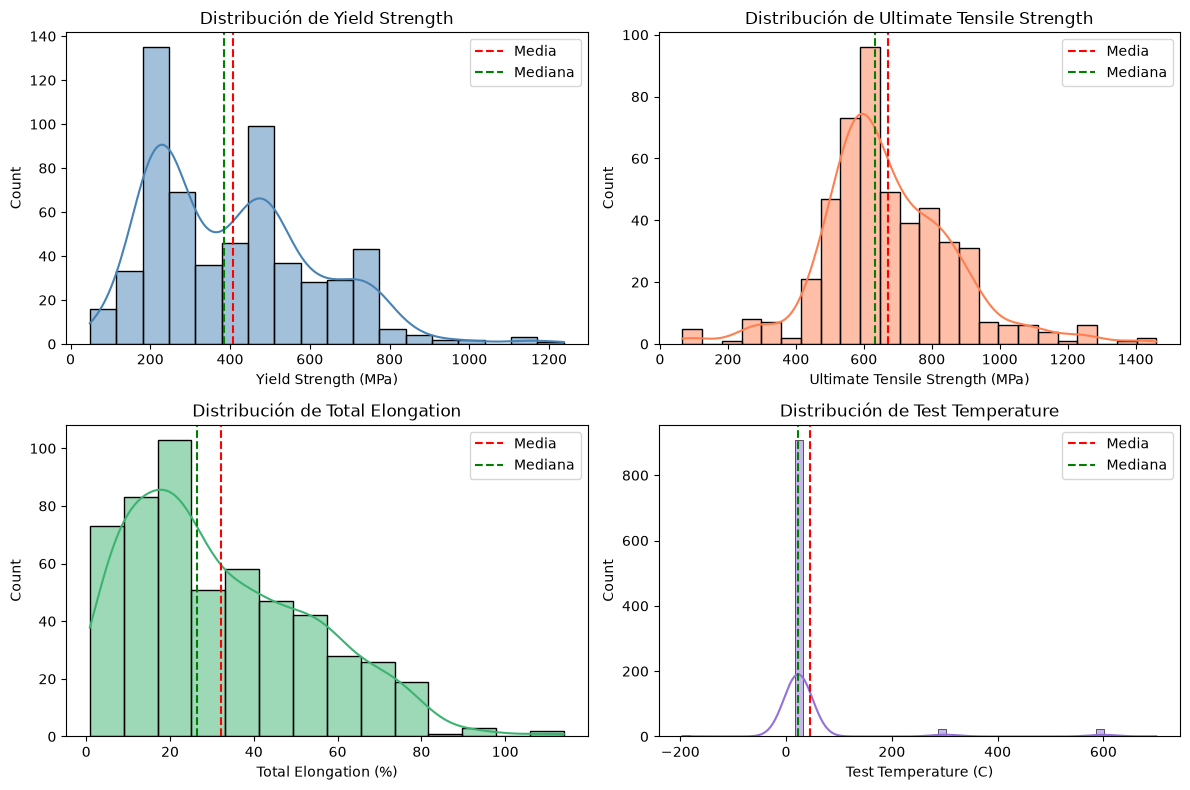

In [ ]:
# Visualización de distribuciones y medidas de tendencia central
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Yield Strength
sns.histplot(data=df_analisis, x='Yield Strength (MPa)', kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribución de Yield Strength')
axes[0, 0].axvline(df_analisis['Yield Strength (MPa)'].mean(), color='red', linestyle='--', label='Media')
axes[0, 0].axvline(df_analisis['Yield Strength (MPa)'].median(), color='green', linestyle='--', label='Mediana')
axes[0, 0].legend()

# Ultimate Tensile Strength
sns.histplot(data=df_analisis, x='Ultimate Tensile Strength (MPa)', kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Distribución de Ultimate Tensile Strength')
axes[0, 1].axvline(df_analisis['Ultimate Tensile Strength (MPa)'].mean(), color='red', linestyle='--', label='Media')
axes[0, 1].axvline(df_analisis['Ultimate Tensile Strength (MPa)'].median(), color='green', linestyle='--', label='Mediana')
axes[0, 1].legend()

# Total Elongation
sns.histplot(data=df_analisis, x='Total Elongation (%)', kde=True, ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Distribución de Total Elongation')
axes[1, 0].axvline(df_analisis['Total Elongation (%)'].mean(), color='red', linestyle='--', label='Media')
axes[1, 0].axvline(df_analisis['Total Elongation (%)'].median(), color='green', linestyle='--', label='Mediana')
axes[1, 0].legend()

# Test Temperature
sns.histplot(data=df_analisis, x='Test Temperature (C)', kde=True, ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Distribución de Test Temperature')
axes[1, 1].axvline(df_analisis['Test Temperature (C)'].mean(), color='red', linestyle='--', label='Media')
axes[1, 1].axvline(df_analisis['Test Temperature (C)'].median(), color='green', linestyle='--', label='Mediana')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

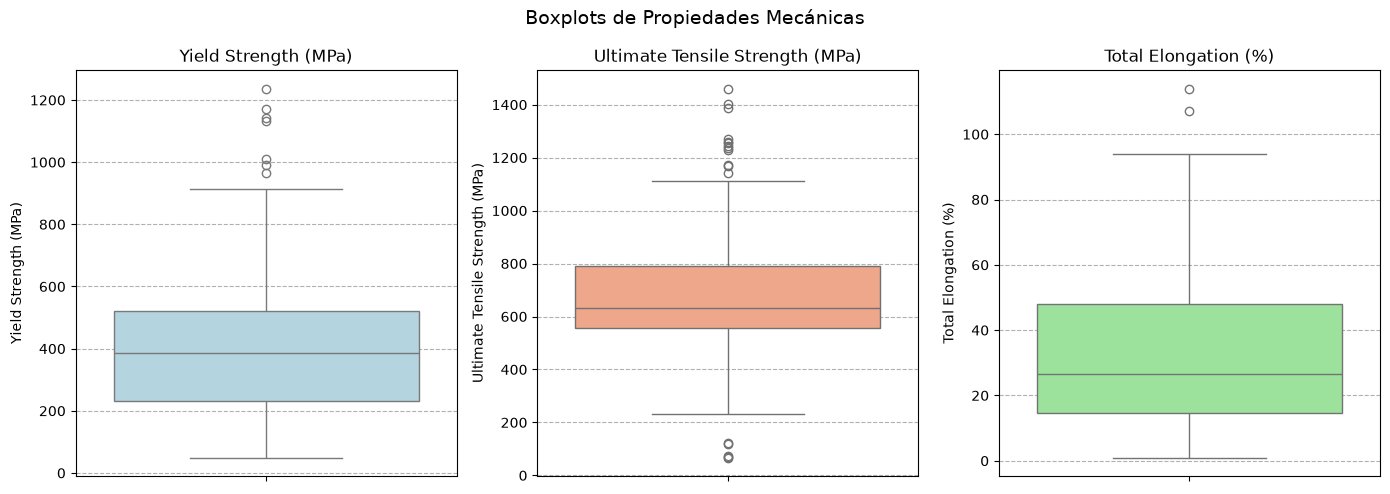

In [35]:
# Visualización de boxplots para propiedades mecánicas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Yield Strength
sns.boxplot(data=df_analisis, y='Yield Strength (MPa)', ax=axes[0], color='lightblue')
axes[0].set_title('Yield Strength (MPa)')
axes[0].grid(axis='y', linestyle='--')

# Ultimate Tensile Strength
sns.boxplot(data=df_analisis, y='Ultimate Tensile Strength (MPa)', ax=axes[1], color='lightsalmon')
axes[1].set_title('Ultimate Tensile Strength (MPa)')
axes[1].grid(axis='y', linestyle='--')

# Total Elongation
sns.boxplot(data=df_analisis, y='Total Elongation (%)', ax=axes[2], color='lightgreen')
axes[2].set_title('Total Elongation (%)')
axes[2].grid(axis='y', linestyle='--')

plt.suptitle('Boxplots de Propiedades Mecánicas', fontsize=14)
plt.tight_layout()
plt.show()

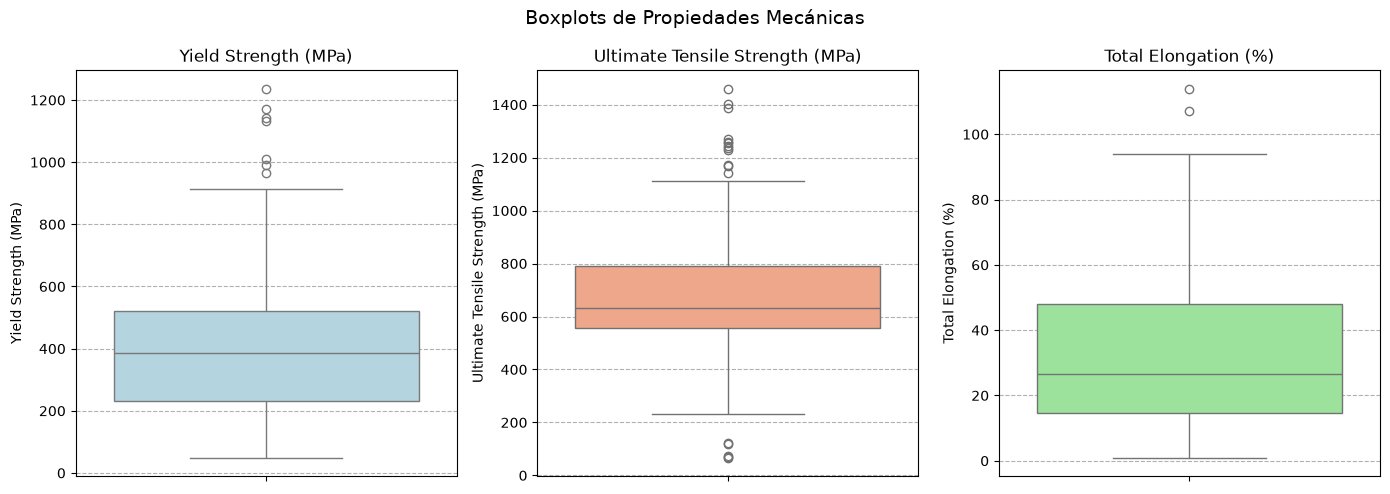

In [36]:
# Visualización de boxplots para propiedades mecánicas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Yield Strength
sns.boxplot(data=df_analisis, y='Yield Strength (MPa)', ax=axes[0], color='lightblue')
axes[0].set_title('Yield Strength (MPa)')
axes[0].grid(axis='y', linestyle='--')

# Ultimate Tensile Strength
sns.boxplot(data=df_analisis, y='Ultimate Tensile Strength (MPa)', ax=axes[1], color='lightsalmon')
axes[1].set_title('Ultimate Tensile Strength (MPa)')
axes[1].grid(axis='y', linestyle='--')

# Total Elongation
sns.boxplot(data=df_analisis, y='Total Elongation (%)', ax=axes[2], color='lightgreen')
axes[2].set_title('Total Elongation (%)')
axes[2].grid(axis='y', linestyle='--')

plt.suptitle('Boxplots de Propiedades Mecánicas', fontsize=14)
plt.tight_layout()
plt.show()

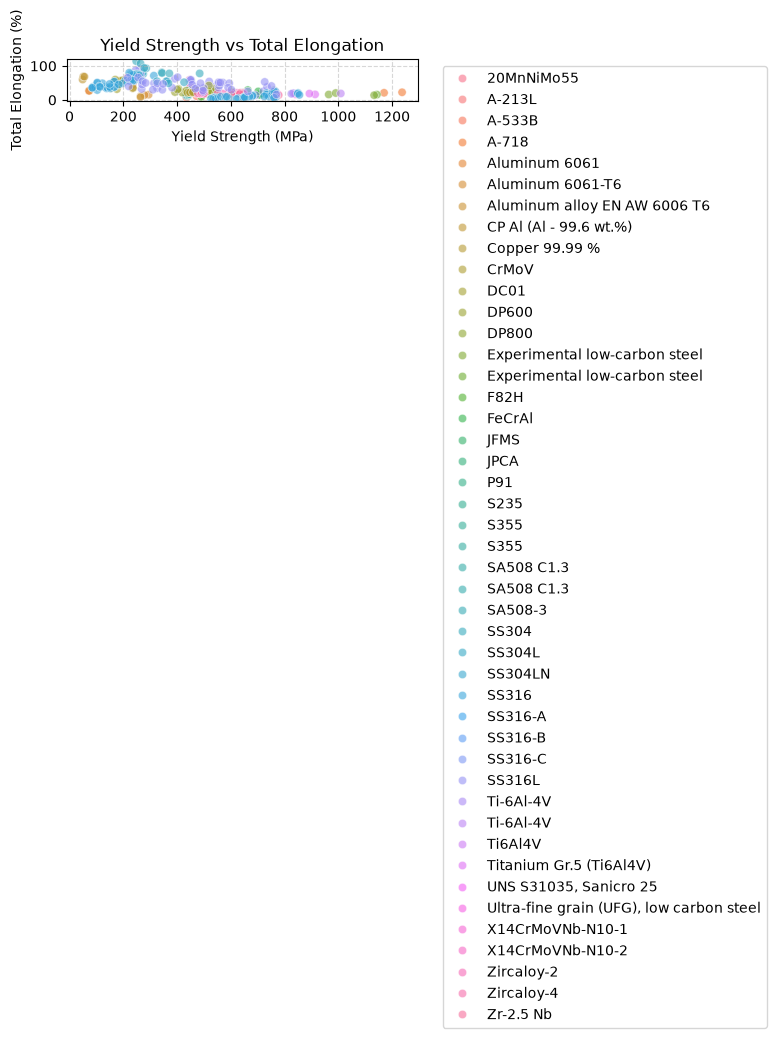

In [ ]:
# Visualización de dispersión entre Yield Strength y Total Elongation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_analisis, x='Yield Strength (MPa)', y='Total Elongation (%)', 
                hue='Material', alpha=0.6)
plt.title('Yield Strength vs Total Elongation')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Total Elongation (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlación (Pearson) entre variables relevantes
cols_corr = [
    'Yield Strength (MPa)', 'Ultimate Tensile Strength (MPa)',
    'Uniform Elongation (%)', 'Total Elongation (%)',
    'W (wt.%)', 'Sn (wt.%)', 'Zr (wt.%)', 'Al (wt.%)', 'O (wt.,%)',
    'C (wt.%)', 'Grain size (um)', 'Irradiation Dose (dpa)',
    'Test Temperature (C)'
]
matriz_corr = df_analisis[cols_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
plt.show()


In [ ]:
# Dispersión entre Yield Strength y Ultimate Tensile Strength
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_analisis, x='Yield Strength (MPa)',
                y='Ultimate Tensile Strength (MPa)',
                hue='Material', alpha=0.6)
plt.title('Resistencia a la fluencia vs Resistencia a la tracción')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Ultimate Tensile Strength (MPa)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Resumen

Este dataset trae datos de propiedades mecánicas de probetas de tension: 
1050 registros y 55 variables, de las cuales 41 son numericas y 14 categoricas.

Relaciones

- Resistencia por partes: el Yield Strength y el Ultimate Tensile Strength
  van muy de la mano (correlacion ~0.82). Si sube una, casi siempre sube la otra.
- Ductilidad: la elongacion uniforme y la total estan muy relacionadas
  (~0.94), o sea que miden practicamente lo mismo.
- trade-off: los materiales más resistentes suelen ser los que menos
  se estiran antes de romperse (relación negativa entre resistencia y elongacion).
- La importancia de la composicion, sobre todo el Tungsteno (W) y también la irradiacion hacen
  que suba la resistencia y baje la elongacion.

